In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    classification_report, confusion_matrix,
    roc_auc_score, roc_curve, ConfusionMatrixDisplay
)
from xgboost import XGBClassifier
import joblib
import warnings
warnings.filterwarnings("ignore")

print("All libraries imported successfully")

All libraries imported successfully


In [2]:
rfm = pd.read_csv("../data/rfm_segments.csv")

print(f"RFM shape: {rfm.shape}")
print(f"Columns: {list(rfm.columns)}")
rfm.head()

RFM shape: (5878, 5)
Columns: ['CustomerID', 'Recency', 'Frequency', 'Monetary', 'Cluster']


,CustomerID,Recency,Frequency,Monetary,Cluster
0,12346,326,12,77556.46,1
1,12347,2,8,5633.32,1
2,12348,75,5,2019.40,1
3,12349,19,4,4428.69,1
4,12350,310,1,334.40,0


In [3]:
print("Cluster distribution:")
print(rfm["Cluster"].value_counts().sort_index())

Cluster distribution:
Cluster
0    1998
1    3841
2      35
3       4
Name: count, dtype: int64


In [4]:
CHURN_THRESHOLD = 90  # days

rfm["Churned"] = (rfm["Recency"] > CHURN_THRESHOLD).astype(int)

churn_counts = rfm["Churned"].value_counts()
churn_pct    = rfm["Churned"].value_counts(normalize=True) * 100

print("=" * 40)
print("Churn Label Distribution")
print("=" * 40)
print(f"  Active  (0): {churn_counts[0]:>6}  ({churn_pct[0]:.1f}%)")
print(f"  Churned (1): {churn_counts[1]:>6}  ({churn_pct[1]:.1f}%)")
print("=" * 40)

Churn Label Distribution
  Active  (0):   2889  (49.1%)
  Churned (1):   2989  (50.9%)


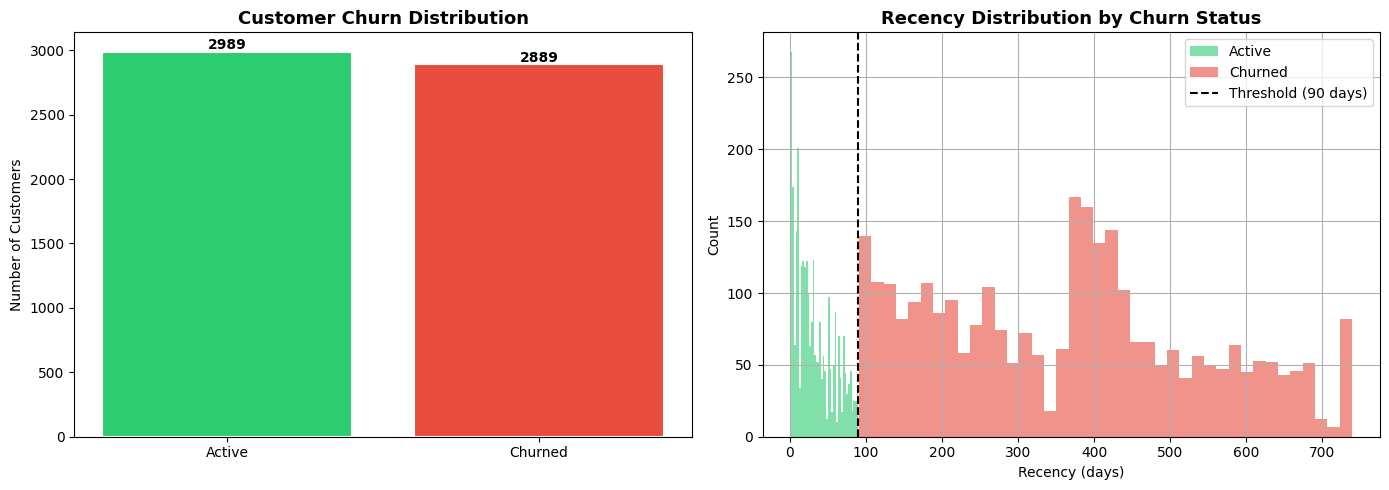

Saved churn_distribution.png


In [5]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].bar(["Active", "Churned"], churn_counts.values,
            color=["#2ecc71", "#e74c3c"], edgecolor="white", linewidth=1.5)
axes[0].set_title("Customer Churn Distribution", fontsize=13, fontweight="bold")
axes[0].set_ylabel("Number of Customers")
for i, v in enumerate(churn_counts.values):
    axes[0].text(i, v + 20, str(v), ha="center", fontweight="bold")

rfm[rfm["Churned"]==0]["Recency"].hist(bins=40, alpha=0.6, color="#2ecc71",
                                         label="Active", ax=axes[1])
rfm[rfm["Churned"]==1]["Recency"].hist(bins=40, alpha=0.6, color="#e74c3c",
                                         label="Churned", ax=axes[1])
axes[1].axvline(CHURN_THRESHOLD, color="black", linestyle="--",
                label=f"Threshold ({CHURN_THRESHOLD} days)")
axes[1].set_title("Recency Distribution by Churn Status", fontsize=13, fontweight="bold")
axes[1].set_xlabel("Recency (days)")
axes[1].set_ylabel("Count")
axes[1].legend()

plt.tight_layout()
plt.savefig("../data/churn_prediction_images/churn_distribution.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved churn_distribution.png")

In [6]:
rfm["AvgOrderValue"] = rfm["Monetary"] / rfm["Frequency"]

FEATURES = ["Recency", "Frequency", "Monetary", "AvgOrderValue", "Cluster"]
TARGET   = "Churned"

X = rfm[FEATURES]
y = rfm[TARGET]

print(f"Features shape : {X.shape}")
print(f"Target shape   : {y.shape}")
print(f"\nFeature summary:")
X.describe().round(2)

Features shape : (5878, 5)
Target shape   : (5878,)

Feature summary:


,Recency,Frequency,Monetary,AvgOrderValue,Cluster
count,5878.00,5878.00,5878.00,5878.00,5878.00
mean,201.33,6.29,3018.62,391.73,0.67
std,209.34,13.01,14737.73,1215.07,0.49
min,1.00,1.00,2.95,2.95,0.00
25%,26.00,1.00,348.76,181.65,0.00
50%,96.00,3.00,898.92,285.07,1.00
75%,380.00,7.00,2307.09,420.57,1.00
max,739.00,398.00,608821.65,84236.25,3.00


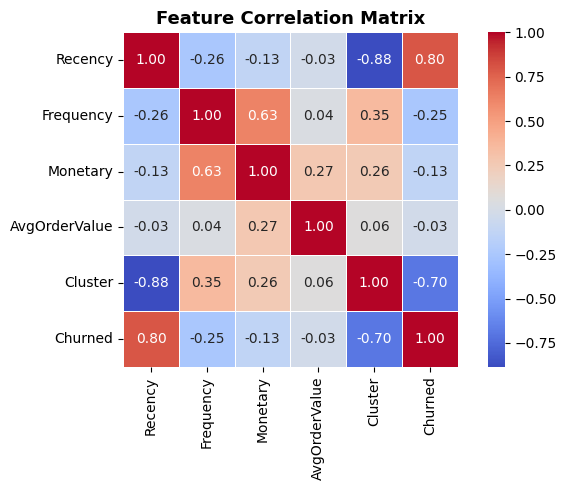

Saved correlation_heatmap.png


In [7]:
corr_data = rfm[FEATURES + [TARGET]].corr()

plt.figure(figsize=(7, 5))
sns.heatmap(corr_data, annot=True, fmt=".2f", cmap="coolwarm",
            linewidths=0.5, square=True)
plt.title("Feature Correlation Matrix", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.savefig("../data/churn_prediction_images/correlation_heatmap.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved correlation_heatmap.png")

In [8]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size    = 0.2,
    random_state = 42,
    stratify     = y       # keeps churn ratio balanced in both sets
)

print(f"Train set : {X_train.shape[0]} rows  |  Churn rate: {y_train.mean()*100:.1f}%")
print(f"Test set  : {X_test.shape[0]} rows  |  Churn rate: {y_test.mean()*100:.1f}%")

Train set : 4702 rows  |  Churn rate: 50.9%
Test set  : 1176 rows  |  Churn rate: 50.9%


In [9]:
neg = (y_train == 0).sum()
pos = (y_train == 1).sum()
scale_weight = neg / pos
print(f"Class imbalance weight (scale_pos_weight): {scale_weight:.2f}")

model = XGBClassifier(
    n_estimators      = 300,
    max_depth         = 5,
    learning_rate     = 0.05,
    subsample         = 0.8,
    colsample_bytree  = 0.8,
    scale_pos_weight  = scale_weight,
    use_label_encoder = False,
    eval_metric       = "logloss",
    random_state      = 42,
    n_jobs            = -1
)

model.fit(
    X_train, y_train,
    eval_set              = [(X_test, y_test)],
    verbose               = 50
)

print("\nModel training complete")

Class imbalance weight (scale_pos_weight): 0.97
[0]	validation_0-logloss:0.64454
[50]	validation_0-logloss:0.06055
[100]	validation_0-logloss:0.00883
[150]	validation_0-logloss:0.00160
[200]	validation_0-logloss:0.00072
[250]	validation_0-logloss:0.00069
[299]	validation_0-logloss:0.00067

Model training complete


In [10]:
y_pred      = model.predict(X_test)
y_pred_prob = model.predict_proba(X_test)[:, 1]

roc_auc = roc_auc_score(y_test, y_pred_prob)

print("=" * 50)
print("         MODEL EVALUATION REPORT")
print("=" * 50)
print(classification_report(y_test, y_pred,
                              target_names=["Active", "Churned"]))
print(f"ROC-AUC Score : {roc_auc:.4f}")
print("=" * 50)

         MODEL EVALUATION REPORT
              precision    recall  f1-score   support

      Active       1.00      1.00      1.00       578
     Churned       1.00      1.00      1.00       598

    accuracy                           1.00      1176
   macro avg       1.00      1.00      1.00      1176
weighted avg       1.00      1.00      1.00      1176

ROC-AUC Score : 1.0000


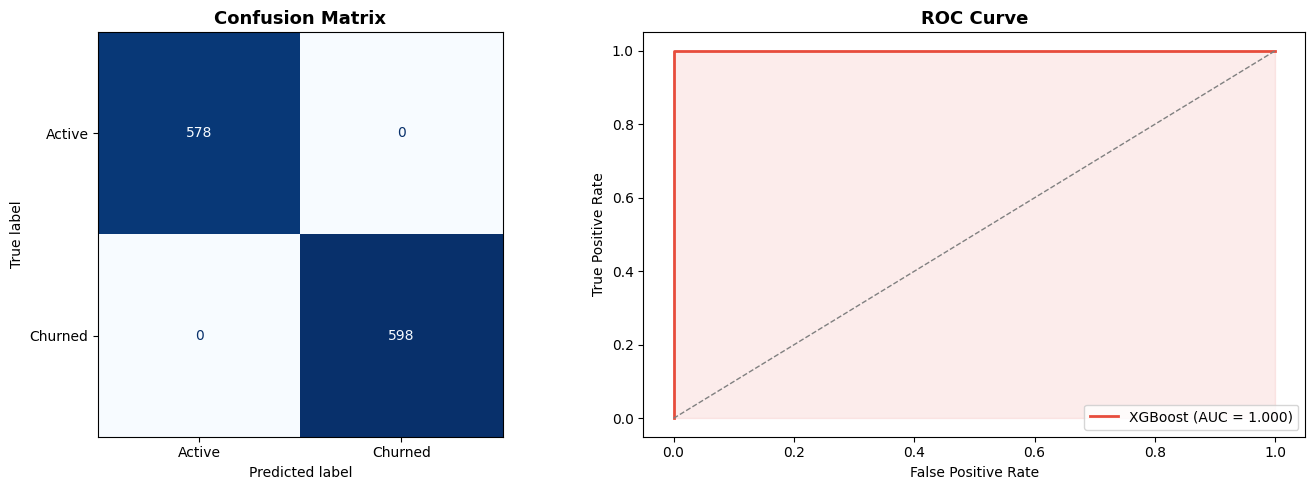

Saved model_evaluation.png


In [11]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm,
                               display_labels=["Active", "Churned"])
disp.plot(ax=axes[0], colorbar=False, cmap="Blues")
axes[0].set_title("Confusion Matrix", fontsize=13, fontweight="bold")

fpr, tpr, _ = roc_curve(y_test, y_pred_prob)
axes[1].plot(fpr, tpr, color="#e74c3c", lw=2,
             label=f"XGBoost (AUC = {roc_auc:.3f})")
axes[1].plot([0, 1], [0, 1], color="gray", linestyle="--", lw=1)
axes[1].fill_between(fpr, tpr, alpha=0.1, color="#e74c3c")
axes[1].set_xlabel("False Positive Rate")
axes[1].set_ylabel("True Positive Rate")
axes[1].set_title("ROC Curve", fontsize=13, fontweight="bold")
axes[1].legend(loc="lower right")

plt.tight_layout()
plt.savefig("../data/churn_prediction_images/model_evaluation.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved model_evaluation.png")

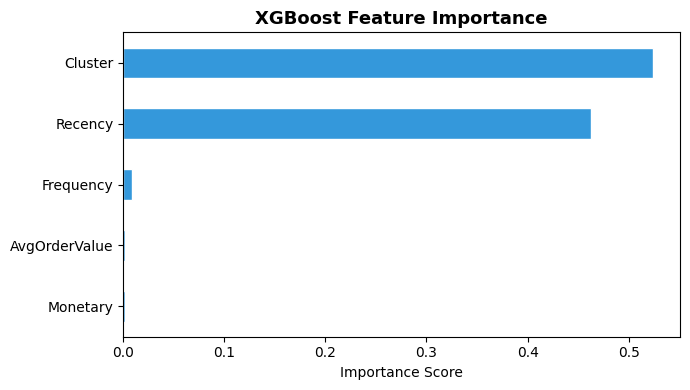

Saved feature_importance.png


In [12]:
feat_imp = pd.Series(model.feature_importances_, index=FEATURES).sort_values(ascending=True)

plt.figure(figsize=(7, 4))
feat_imp.plot(kind="barh", color="#3498db", edgecolor="white")
plt.title("XGBoost Feature Importance", fontsize=13, fontweight="bold")
plt.xlabel("Importance Score")
plt.tight_layout()
plt.savefig("../data/churn_prediction_images/feature_importance.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved feature_importance.png")

In [13]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
cv_scores = cross_val_score(model, X, y, cv=cv, scoring="roc_auc", n_jobs=-1)

print("5-Fold Cross-Validation ROC-AUC Scores:")
for i, s in enumerate(cv_scores, 1):
    print(f"  Fold {i}: {s:.4f}")
print(f"\n  Mean  : {cv_scores.mean():.4f}")
print(f"  Std   : {cv_scores.std():.4f}")

5-Fold Cross-Validation ROC-AUC Scores:
  Fold 1: 1.0000
  Fold 2: 1.0000
  Fold 3: 1.0000
  Fold 4: 1.0000
  Fold 5: 1.0000

  Mean  : 1.0000
  Std   : 0.0000


In [14]:
cluster_profile = rfm.groupby("Cluster").agg(
    Avg_Recency   = ("Recency",   "mean"),
    Avg_Frequency = ("Frequency", "mean"),
    Avg_Monetary  = ("Monetary",  "mean"),
    Count         = ("CustomerID", "count"),
    Churn_Rate    = ("Churned",   "mean")
).round(2)

cluster_profile["Churn_Rate"] = (cluster_profile["Churn_Rate"] * 100).round(1)
print("Cluster Profiles (before labelling):")
print(cluster_profile.to_string())

Cluster Profiles (before labelling):
         Avg_Recency  Avg_Frequency  Avg_Monetary  Count  Churn_Rate
Cluster                                                             
0             463.03           2.21        765.24   1998       100.0
1              67.01           7.31       3009.40   3841        26.0
2              25.94         103.71      83086.08     35         6.0
3               3.50         212.50     436835.79      4         0.0


In [15]:
cluster_profile["Monetary_Rank"] = cluster_profile["Avg_Monetary"].rank(ascending=False).astype(int)

n_clusters = rfm["Cluster"].nunique()
print(f"\nNumber of clusters detected: {n_clusters}")

if n_clusters == 4:
    rank_to_label = {
        1: "Champions",
        2: "Loyal Customers",
        3: "At Risk",
        4: "Lost Customers"
    }
elif n_clusters == 3:
    rank_to_label = {
        1: "Champions",
        2: "At Risk",
        3: "Lost Customers"
    }
else:
    rank_to_label = {r: f"Segment {r}" for r in range(1, n_clusters + 1)}

cluster_profile["Segment_Label"] = cluster_profile["Monetary_Rank"].map(rank_to_label)
cluster_id_to_label = cluster_profile["Segment_Label"].to_dict()

rfm["Segment_Label"] = rfm["Cluster"].map(cluster_id_to_label)
print("\nCluster → Segment Labels:")
print(cluster_id_to_label)


Number of clusters detected: 4

Cluster → Segment Labels:
{0: 'Lost Customers', 1: 'At Risk', 2: 'Loyal Customers', 3: 'Champions'}


In [16]:
INTERVENTION_MAP = {
    ("Champions",        "High"):   "VIP Win-Back: Personal call + exclusive loyalty reward + free shipping",
    ("Champions",        "Medium"): "Early Alert: Send personalised product recommendation based on past purchases",
    ("Champions",        "Low"):    "Retain: Enrol in VIP loyalty program, send thank-you offer",

    ("Loyal Customers",  "High"):   "Urgent Re-engage: 20% discount coupon + highlight new arrivals",
    ("Loyal Customers",  "Medium"): "Nudge: Send reminder email + product recommendation + limited offer",
    ("Loyal Customers",  "Low"):    "Nurture: Monthly newsletter + loyalty point updates",

    ("At Risk",          "High"):   "Recovery: Time-limited 30% win-back discount + survey to understand why",
    ("At Risk",          "Medium"): "Re-engage: Best-seller showcase email + 15% discount",
    ("At Risk",          "Low"):    "Monitor: Add to re-engagement drip campaign",

    ("Lost Customers",   "High"):   "Last Chance: Final win-back email + max discount. If no response, deprioritise.",
    ("Lost Customers",   "Medium"): "Re-activation: Welcome-back campaign + highlight what's new",
    ("Lost Customers",   "Low"):    "Low Priority: Seasonal promotional email only",
}

FALLBACK_INTERVENTION = {
    "High":   "High Risk: Immediate re-engagement campaign required",
    "Medium": "Medium Risk: Send personalised discount offer",
    "Low":    "Low Risk: Continue standard nurture sequence"
}

print("Intervention map defined")

Intervention map defined


In [17]:
rfm["Churn_Probability"] = model.predict_proba(X)[:, 1]
rfm["Churn_Prediction"]  = model.predict(X)

def risk_tier(prob):
    if prob >= 0.70:
        return "High"
    elif prob >= 0.40:
        return "Medium"
    else:
        return "Low"

rfm["Risk_Tier"] = rfm["Churn_Probability"].apply(risk_tier)

def get_intervention(row):
    key = (row["Segment_Label"], row["Risk_Tier"])
    return INTERVENTION_MAP.get(key, FALLBACK_INTERVENTION[row["Risk_Tier"]])

rfm["Recommended_Action"] = rfm.apply(get_intervention, axis=1)

print(f"Scored {len(rfm)} customers")
print("\nRisk Tier Distribution:")
print(rfm["Risk_Tier"].value_counts())

Scored 5878 customers

Risk Tier Distribution:
Risk_Tier
High      2987
Low       2889
Medium       2
Name: count, dtype: int64


In [18]:
output_cols = [
    "CustomerID", "Recency", "Frequency", "Monetary",
    "Segment_Label", "Churn_Probability", "Risk_Tier", "Recommended_Action"
]

print("=" * 80)
print("SAMPLE OUTPUT — HIGH RISK CUSTOMERS")
print("=" * 80)
rfm[rfm["Risk_Tier"] == "High"][output_cols].sort_values(
    "Churn_Probability", ascending=False
).head(10)

SAMPLE OUTPUT — HIGH RISK CUSTOMERS


,CustomerID,Recency,Frequency,Monetary,Segment_Label,Churn_Probability,Risk_Tier,Recommended_Action
5500,17908,374,5,1411.54,Lost Customers,0.999951,High,Last Chance: Final win-back email + max discou...
4534,16926,371,5,1421.35,Lost Customers,0.999951,High,Last Chance: Final win-back email + max discou...
5307,17714,321,5,1410.18,Lost Customers,0.999951,High,Last Chance: Final win-back email + max discou...
1491,13855,501,4,1310.34,Lost Customers,0.999950,High,Last Chance: Final win-back email + max discou...
3783,16167,414,5,1386.12,Lost Customers,0.999948,High,Last Chance: Final win-back email + max discou...
1025,13382,281,5,1387.58,Lost Customers,0.999948,High,Last Chance: Final win-back email + max discou...
1948,14316,422,5,1370.34,Lost Customers,0.999948,High,Last Chance: Final win-back email + max discou...
3911,16296,626,4,1313.67,Lost Customers,0.999947,High,Last Chance: Final win-back email + max discou...
1769,14136,401,5,1570.81,Lost Customers,0.999945,High,Last Chance: Final win-back email + max discou...
1819,14186,427,5,1550.63,Lost Customers,0.999945,High,Last Chance: Final win-back email + max discou...


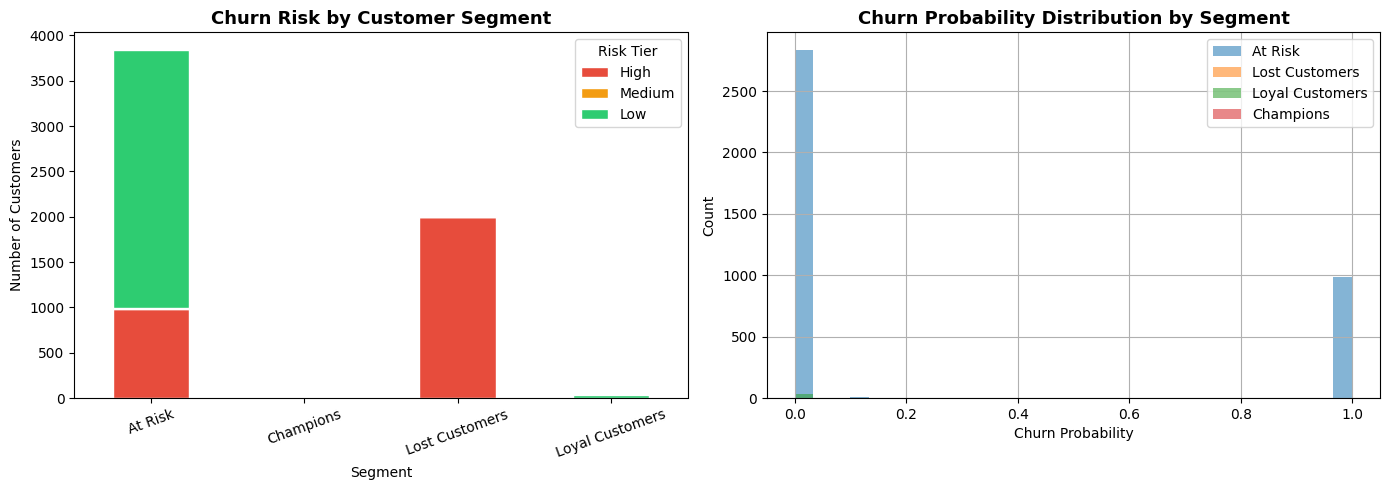

Saved churn_risk_by_segment.png


In [19]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

risk_by_seg = rfm.groupby(["Segment_Label", "Risk_Tier"]).size().unstack(fill_value=0)
risk_colors = {"High": "#e74c3c", "Medium": "#f39c12", "Low": "#2ecc71"}
risk_by_seg[[c for c in ["High", "Medium", "Low"] if c in risk_by_seg.columns]].plot(
    kind="bar", stacked=True, ax=axes[0],
    color=[risk_colors[c] for c in ["High", "Medium", "Low"] if c in risk_by_seg.columns],
    edgecolor="white"
)
axes[0].set_title("Churn Risk by Customer Segment", fontsize=13, fontweight="bold")
axes[0].set_xlabel("Segment")
axes[0].set_ylabel("Number of Customers")
axes[0].tick_params(axis="x", rotation=20)
axes[0].legend(title="Risk Tier")

for seg in rfm["Segment_Label"].unique():
    rfm[rfm["Segment_Label"] == seg]["Churn_Probability"].hist(
        bins=30, alpha=0.55, ax=axes[1], label=seg
    )
axes[1].set_title("Churn Probability Distribution by Segment", fontsize=13, fontweight="bold")
axes[1].set_xlabel("Churn Probability")
axes[1].set_ylabel("Count")
axes[1].legend()

plt.tight_layout()
plt.savefig("../data/churn_prediction_images/churn_risk_by_segment.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved churn_risk_by_segment.png")

In [20]:
action_summary = rfm["Risk_Tier"].value_counts().reset_index()
action_summary.columns = ["Risk_Tier", "Customer_Count"]

revenue_at_risk = rfm.groupby("Risk_Tier")["Monetary"].sum().reset_index()
revenue_at_risk.columns = ["Risk_Tier", "Revenue_At_Risk"]

summary_table = action_summary.merge(revenue_at_risk, on="Risk_Tier")
summary_table["Revenue_At_Risk"] = summary_table["Revenue_At_Risk"].round(2)

print("=" * 55)
print("      BUSINESS IMPACT SUMMARY")
print("=" * 55)
print(summary_table.to_string(index=False))
print("=" * 55)

total_high_risk_revenue = revenue_at_risk[revenue_at_risk["Risk_Tier"]=="High"]["Revenue_At_Risk"].values
if len(total_high_risk_revenue) > 0:
    print(f"\nRevenue at risk from HIGH risk customers: £{total_high_risk_revenue[0]:,.2f}")

      BUSINESS IMPACT SUMMARY
Risk_Tier  Customer_Count  Revenue_At_Risk
     High            2987       3465458.95
      Low            2889      14274670.60
   Medium               2          3299.63

Revenue at risk from HIGH risk customers: £3,465,458.95


In [21]:
churn_report = rfm[output_cols].copy()
churn_report["Churn_Probability"] = churn_report["Churn_Probability"].round(4)
churn_report.to_csv("../data/customer_churn_report.csv", index=False)
print(f"Saved customer_churn_report.csv — {len(churn_report)} customers")

high_risk = churn_report[churn_report["Risk_Tier"] == "High"].sort_values(
    "Churn_Probability", ascending=False
)
high_risk.to_csv("../data/high_risk_customers.csv", index=False)
print(f"Saved high_risk_customers.csv — {len(high_risk)} customers")

summary_table.to_csv("../data/intervention_summary.csv", index=False)
print(f"Saved intervention_summary.csv")

joblib.dump(model, "../data/churn_model.pkl")
print(f"Saved churn_model.pkl")

print("\nAll outputs saved. Ready for Flask dashboard!")

Saved customer_churn_report.csv — 5878 customers
Saved high_risk_customers.csv — 2987 customers
Saved intervention_summary.csv
Saved churn_model.pkl

All outputs saved. Ready for Flask dashboard!
